# Sunčica Sakić 193m/18 MB

Numela 1

# ZADATAK 7

Na osnovu podataka iz fajla global_health_nutrition_data.csv za svaku evropsku zemlju formirati Geršgorinove krugove za Vandermondovu matricu vremenske serije indikatora Population, total (kod je SP.POP.TOTL). Pored krugova, na istom grafikonu prikazati i karakteristične korene.

In [1]:
import pandas as pd
import numpy as np
import scipy
from scipy import linalg as la
import matplotlib
from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection
import matplotlib.pyplot as plt
import os
import sys
plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

In [2]:
path2file = r"C:\Users\zeks\Downloads\global_health_nutrition_data.csv" 

In [3]:
data = pd.read_csv(os.path.normpath(path2file)) #učitavanje podataka
data = data[data['Indicator Code']== 'SP.POP.TOTL'] 

In [4]:
european_code =['ALB','AND','AUT','BLR','BEL','BIH','BGR','HRV','CIP','CZE','DNK','EST','FRO','FIN','FRA','DEU','GIB','GRC','HUN','ISL','IRL','ITA','LVA','LIE','LTU','LUX','MKD','MLT','MDA','MCO','MNE','NLD','NOR','POL','PRT','ROU','RUS','SMR','SRB','SVK','SVN','ESP','SWE','CHE','UKR','GBR','VAT']

In [5]:
european_countries=[]
for i in list(range(data.shape[0])):
    european_countries.append(data['Country Code'].values[i] in european_code)
data=data[european_countries] #filtriranje evropskih zemalja
data

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,Unnamed: 60
14757,Albania,ALB,"Population, total",SP.POP.TOTL,1608800.0,1659800.0,1711319.0,1762621.0,1814135.0,1864791.0,...,2970017.0,2947314.0,2927519.0,2913021.0,2904780.0,2900247.0,2896652.0,2893654.0,2889167.0,NaN
18207,Austria,AUT,"Population, total",SP.POP.TOTL,7047539.0,7086299.0,7129864.0,7175811.0,7223801.0,7270889.0,...,8295487.0,8321496.0,8343323.0,8363404.0,8391643.0,8429991.0,8479375.0,8541575.0,8611088.0,NaN
20277,Belarus,BLR,"Population, total",SP.POP.TOTL,8198000.0,8271216.0,8351928.0,8437232.0,8524224.0,8610000.0,...,9560000.0,9528000.0,9507000.0,9490000.0,9473000.0,9464000.0,9466000.0,9483000.0,9513000.0,NaN
20622,Belgium,BEL,"Population, total",SP.POP.TOTL,9153489.0,9183948.0,9220578.0,9289770.0,9378113.0,9463667.0,...,10625700.0,10709973.0,10796493.0,10895586.0,11047744.0,11128246.0,11182817.0,11231213.0,11285721.0,NaN
22692,Bosnia and Herzegovina,BIH,"Population, total",SP.POP.TOTL,3214520.0,3277096.0,3341809.0,3406466.0,3468083.0,3524596.0,...,3840418.0,3839749.0,3837732.0,3835258.0,3832310.0,3828419.0,3823533.0,3817554.0,3810416.0,NaN
24417,Bulgaria,BGR,"Population, total",SP.POP.TOTL,7867374.0,7943118.0,8012946.0,8078145.0,8144340.0,8204168.0,...,7545338.0,7492561.0,7444443.0,7395599.0,7348328.0,7305888.0,7265115.0,7223938.0,7177991.0,NaN
30972,Croatia,HRV,"Population, total",SP.POP.TOTL,4140000.0,4171672.0,4202104.0,4231408.0,4259680.0,4287000.0,...,4436000.0,4434508.0,4429078.0,4417781.0,4280622.0,4267558.0,4255689.0,4238389.0,4224404.0,NaN
32352,Czech Republic,CZE,"Population, total",SP.POP.TOTL,9602006.0,9586651.0,9624660.0,9670685.0,9727804.0,9779358.0,...,10298828.0,10384603.0,10443936.0,10474410.0,10496088.0,10510785.0,10514272.0,10525347.0,10551219.0,NaN
32697,Denmark,DNK,"Population, total",SP.POP.TOTL,4579603.0,4611687.0,4647727.0,4684483.0,4722072.0,4759012.0,...,5461438.0,5493621.0,5523095.0,5547683.0,5570572.0,5591572.0,5614932.0,5643475.0,5676002.0,NaN
35802,Estonia,EST,"Population, total",SP.POP.TOTL,1211537.0,1225077.0,1241623.0,1258857.0,1277086.0,1294566.0,...,1340680.0,1337090.0,1334515.0,1331475.0,1327439.0,1322696.0,1317997.0,1314545.0,1311998.0,NaN


In [6]:
data=data.drop(columns=['Country Name','Country Code','Indicator Name','Indicator Code','Unnamed: 60']) #izbacujemo višak kolona
data

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
14757,1608800.0,1659800.0,1711319.0,1762621.0,1814135.0,1864791.0,1914573.0,1965598.0,2022272.0,2081695.0,...,2992547.0,2970017.0,2947314.0,2927519.0,2913021.0,2904780.0,2900247.0,2896652.0,2893654.0,2889167.0
18207,7047539.0,7086299.0,7129864.0,7175811.0,7223801.0,7270889.0,7322066.0,7376998.0,7415403.0,7441055.0,...,8268641.0,8295487.0,8321496.0,8343323.0,8363404.0,8391643.0,8429991.0,8479375.0,8541575.0,8611088.0
20277,8198000.0,8271216.0,8351928.0,8437232.0,8524224.0,8610000.0,8696496.0,8785648.0,8874552.0,8960304.0,...,9604000.0,9560000.0,9528000.0,9507000.0,9490000.0,9473000.0,9464000.0,9466000.0,9483000.0,9513000.0
20622,9153489.0,9183948.0,9220578.0,9289770.0,9378113.0,9463667.0,9527807.0,9580991.0,9618756.0,9646032.0,...,10547958.0,10625700.0,10709973.0,10796493.0,10895586.0,11047744.0,11128246.0,11182817.0,11231213.0,11285721.0
22692,3214520.0,3277096.0,3341809.0,3406466.0,3468083.0,3524596.0,3574972.0,3619997.0,3661642.0,3702834.0,...,3838504.0,3840418.0,3839749.0,3837732.0,3835258.0,3832310.0,3828419.0,3823533.0,3817554.0,3810416.0
24417,7867374.0,7943118.0,8012946.0,8078145.0,8144340.0,8204168.0,8258057.0,8310226.0,8369603.0,8434172.0,...,7699020.0,7545338.0,7492561.0,7444443.0,7395599.0,7348328.0,7305888.0,7265115.0,7223938.0,7177991.0
30972,4140000.0,4171672.0,4202104.0,4231408.0,4259680.0,4287000.0,4313000.0,4339000.0,4364000.0,4387000.0,...,4440000.0,4436000.0,4434508.0,4429078.0,4417781.0,4280622.0,4267558.0,4255689.0,4238389.0,4224404.0
32352,9602006.0,9586651.0,9624660.0,9670685.0,9727804.0,9779358.0,9821040.0,9852899.0,9876346.0,9896580.0,...,10238905.0,10298828.0,10384603.0,10443936.0,10474410.0,10496088.0,10510785.0,10514272.0,10525347.0,10551219.0
32697,4579603.0,4611687.0,4647727.0,4684483.0,4722072.0,4759012.0,4797381.0,4835354.0,4864883.0,4891860.0,...,5437272.0,5461438.0,5493621.0,5523095.0,5547683.0,5570572.0,5591572.0,5614932.0,5643475.0,5676002.0
35802,1211537.0,1225077.0,1241623.0,1258857.0,1277086.0,1294566.0,1308597.0,1318946.0,1331214.0,1345249.0,...,1346810.0,1340680.0,1337090.0,1334515.0,1331475.0,1327439.0,1322696.0,1317997.0,1314545.0,1311998.0


In [7]:
data=data.fillna(method ='ffill') #pupunjavamo NaN i inf vrednosti
data

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
14757,1608800.0,1659800.0,1711319.0,1762621.0,1814135.0,1864791.0,1914573.0,1965598.0,2022272.0,2081695.0,...,2992547.0,2970017.0,2947314.0,2927519.0,2913021.0,2904780.0,2900247.0,2896652.0,2893654.0,2889167.0
18207,7047539.0,7086299.0,7129864.0,7175811.0,7223801.0,7270889.0,7322066.0,7376998.0,7415403.0,7441055.0,...,8268641.0,8295487.0,8321496.0,8343323.0,8363404.0,8391643.0,8429991.0,8479375.0,8541575.0,8611088.0
20277,8198000.0,8271216.0,8351928.0,8437232.0,8524224.0,8610000.0,8696496.0,8785648.0,8874552.0,8960304.0,...,9604000.0,9560000.0,9528000.0,9507000.0,9490000.0,9473000.0,9464000.0,9466000.0,9483000.0,9513000.0
20622,9153489.0,9183948.0,9220578.0,9289770.0,9378113.0,9463667.0,9527807.0,9580991.0,9618756.0,9646032.0,...,10547958.0,10625700.0,10709973.0,10796493.0,10895586.0,11047744.0,11128246.0,11182817.0,11231213.0,11285721.0
22692,3214520.0,3277096.0,3341809.0,3406466.0,3468083.0,3524596.0,3574972.0,3619997.0,3661642.0,3702834.0,...,3838504.0,3840418.0,3839749.0,3837732.0,3835258.0,3832310.0,3828419.0,3823533.0,3817554.0,3810416.0
24417,7867374.0,7943118.0,8012946.0,8078145.0,8144340.0,8204168.0,8258057.0,8310226.0,8369603.0,8434172.0,...,7699020.0,7545338.0,7492561.0,7444443.0,7395599.0,7348328.0,7305888.0,7265115.0,7223938.0,7177991.0
30972,4140000.0,4171672.0,4202104.0,4231408.0,4259680.0,4287000.0,4313000.0,4339000.0,4364000.0,4387000.0,...,4440000.0,4436000.0,4434508.0,4429078.0,4417781.0,4280622.0,4267558.0,4255689.0,4238389.0,4224404.0
32352,9602006.0,9586651.0,9624660.0,9670685.0,9727804.0,9779358.0,9821040.0,9852899.0,9876346.0,9896580.0,...,10238905.0,10298828.0,10384603.0,10443936.0,10474410.0,10496088.0,10510785.0,10514272.0,10525347.0,10551219.0
32697,4579603.0,4611687.0,4647727.0,4684483.0,4722072.0,4759012.0,4797381.0,4835354.0,4864883.0,4891860.0,...,5437272.0,5461438.0,5493621.0,5523095.0,5547683.0,5570572.0,5591572.0,5614932.0,5643475.0,5676002.0
35802,1211537.0,1225077.0,1241623.0,1258857.0,1277086.0,1294566.0,1308597.0,1318946.0,1331214.0,1345249.0,...,1346810.0,1340680.0,1337090.0,1334515.0,1331475.0,1327439.0,1322696.0,1317997.0,1314545.0,1311998.0


In [8]:
data =data.reset_index()
data=data.drop(columns=['index']) #reindeksiramo vrste
data

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,1608800.0,1659800.0,1711319.0,1762621.0,1814135.0,1864791.0,1914573.0,1965598.0,2022272.0,2081695.0,...,2992547.0,2970017.0,2947314.0,2927519.0,2913021.0,2904780.0,2900247.0,2896652.0,2893654.0,2889167.0
1,7047539.0,7086299.0,7129864.0,7175811.0,7223801.0,7270889.0,7322066.0,7376998.0,7415403.0,7441055.0,...,8268641.0,8295487.0,8321496.0,8343323.0,8363404.0,8391643.0,8429991.0,8479375.0,8541575.0,8611088.0
2,8198000.0,8271216.0,8351928.0,8437232.0,8524224.0,8610000.0,8696496.0,8785648.0,8874552.0,8960304.0,...,9604000.0,9560000.0,9528000.0,9507000.0,9490000.0,9473000.0,9464000.0,9466000.0,9483000.0,9513000.0
3,9153489.0,9183948.0,9220578.0,9289770.0,9378113.0,9463667.0,9527807.0,9580991.0,9618756.0,9646032.0,...,10547958.0,10625700.0,10709973.0,10796493.0,10895586.0,11047744.0,11128246.0,11182817.0,11231213.0,11285721.0
4,3214520.0,3277096.0,3341809.0,3406466.0,3468083.0,3524596.0,3574972.0,3619997.0,3661642.0,3702834.0,...,3838504.0,3840418.0,3839749.0,3837732.0,3835258.0,3832310.0,3828419.0,3823533.0,3817554.0,3810416.0
5,7867374.0,7943118.0,8012946.0,8078145.0,8144340.0,8204168.0,8258057.0,8310226.0,8369603.0,8434172.0,...,7699020.0,7545338.0,7492561.0,7444443.0,7395599.0,7348328.0,7305888.0,7265115.0,7223938.0,7177991.0
6,4140000.0,4171672.0,4202104.0,4231408.0,4259680.0,4287000.0,4313000.0,4339000.0,4364000.0,4387000.0,...,4440000.0,4436000.0,4434508.0,4429078.0,4417781.0,4280622.0,4267558.0,4255689.0,4238389.0,4224404.0
7,9602006.0,9586651.0,9624660.0,9670685.0,9727804.0,9779358.0,9821040.0,9852899.0,9876346.0,9896580.0,...,10238905.0,10298828.0,10384603.0,10443936.0,10474410.0,10496088.0,10510785.0,10514272.0,10525347.0,10551219.0
8,4579603.0,4611687.0,4647727.0,4684483.0,4722072.0,4759012.0,4797381.0,4835354.0,4864883.0,4891860.0,...,5437272.0,5461438.0,5493621.0,5523095.0,5547683.0,5570572.0,5591572.0,5614932.0,5643475.0,5676002.0
9,1211537.0,1225077.0,1241623.0,1258857.0,1277086.0,1294566.0,1308597.0,1318946.0,1331214.0,1345249.0,...,1346810.0,1340680.0,1337090.0,1334515.0,1331475.0,1327439.0,1322696.0,1317997.0,1314545.0,1311998.0


Naši podaci su sada spremni za dalju analizu. Prvi naš cilj je da definišemo funkciju koja će iscrtavati Gerschgorin-ove krugove za zadatu matricu, kao i karakteristične korene na istom grafiku. Pored toga, ispisaćemo i vrednosti karakterističnih korena date matrice u okviru svakog grafika, sve u cilju bolje reprezentacije istraživanja. Formirajmo sada prethodno navedenu funkciju.

In [9]:
def myGerschgorin(A):
 
    n = len(A)
    eval,evec = la.eig(A)
    print(eval) #ispisuje vrednosti karakterističnih korena za matricu A
    
    patches = []
     
    for i in range(n):
        xi = np.real(A[i,i])
        yi = np.imag(A[i,i]) #ove dve tačke će biti koordinate centra Gerschgorin-ovog kruga u kompleksnoj ravni
        ri = np.sum(np.abs(A[i,:])) - np.abs(A[i,i]) #poluprečnik Gerschgorin-ovog kruga
         
        circle = Circle((xi, yi), ri)
        patches.append(circle) #iscrtava krugove
 
    fig, ax = plt.subplots()
 
    p = PatchCollection(patches, cmap=matplotlib.cm.jet, alpha=0.1)
    ax.add_collection(p)
    plt.axis('equal')
     
    for xi, yi in zip(np.real(eval), np.imag(eval)):
        plt.plot(xi, yi,'o') #iscrtava karakteristične korene od A
     
    plt.show()

U nastavku pravimo Vondermonde-ove matrice od vrsta koje čine naš data. Drugim rečima, formiramo Vondermonde-ove matrice za svaku evropsku zemlju(posmatramo globalno zdravlje u Evropi, tj. njenih zemalja, po godinama). Ovo ćemo učiniti pomoću for petlje koju ćemo istovremeno iskoristiti i za iscrtavanje Gerschgorin-ovih krugova i karakterističnih krugova za Vondermonde-ovu matricu svake evropske zemlje.
Kako karakteristične korene tražimo kod kvadratnih matrica i kako imamo 56 godina(vektor vrsta je dimenzije 56), zaključujemo da će vrednosti u poslednjim kolonama Vondermonde-ove matrice biti jako velike(računar ne može da ih skladišti). Stoga ćemo, pre svega, pronaći maksimalnu vrednosti u data-e, a potom njenom recipročnom vrednošću skalirati sve vrednosti data-e.

In [10]:
m=np.max(data)
M=np.max(m) #max of data
M

148689000.0

[ 1.01094209e+000+0.00000000e+000j  3.54710824e-004+0.00000000e+000j
  2.52790624e-007+0.00000000e+000j  2.67977322e-010+0.00000000e+000j
  3.79927698e-013+0.00000000e+000j  6.51868881e-016+0.00000000e+000j
  1.35459623e-018+0.00000000e+000j  3.73318988e-021+0.00000000e+000j
  1.27943579e-023+0.00000000e+000j  4.65406291e-026+0.00000000e+000j
  2.28145946e-028+0.00000000e+000j  2.21518976e-029+0.00000000e+000j
 -1.63200937e-031+0.00000000e+000j  1.72313561e-032+0.00000000e+000j
 -7.07612319e-034+0.00000000e+000j -2.32461414e-035+0.00000000e+000j
 -5.33166154e-037+0.00000000e+000j  1.37003077e-037+0.00000000e+000j
 -1.53329593e-039+0.00000000e+000j  5.12571628e-041+0.00000000e+000j
  3.25252177e-043+0.00000000e+000j -4.47705867e-045+0.00000000e+000j
  2.19086108e-045+0.00000000e+000j  2.00569607e-047+0.00000000e+000j
  1.63621235e-048+0.00000000e+000j -3.02425763e-050+0.00000000e+000j
  5.94896786e-052+0.00000000e+000j  5.07862492e-054+0.00000000e+000j
  2.41595502e-055+0.00000000e+000j

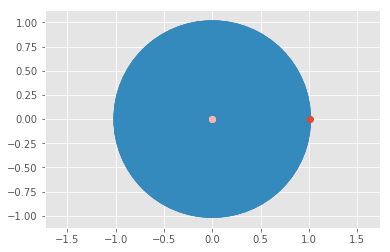

[ 1.04977057e+00+0.00000000e+00j  3.05360017e-04+0.00000000e+00j
  2.10974264e-07+0.00000000e+00j  2.32316118e-10+0.00000000e+00j
  3.50326183e-13+0.00000000e+00j  6.86488633e-16+0.00000000e+00j
  1.30882921e-18+0.00000000e+00j  2.78194186e-21+0.00000000e+00j
  9.70732935e-24+2.38399337e-23j  9.70732935e-24-2.38399337e-23j
 -1.80449225e-24+0.00000000e+00j -3.18189625e-27+1.70197049e-26j
 -3.18189625e-27-1.70197049e-26j  9.05701107e-28+0.00000000e+00j
  1.70084758e-29+0.00000000e+00j -3.35162230e-30+0.00000000e+00j
 -6.32769788e-34+6.85779888e-33j -6.32769788e-34-6.85779888e-33j
 -1.23888031e-35+0.00000000e+00j -7.32887329e-37+0.00000000e+00j
  8.95078846e-38+0.00000000e+00j  6.18192778e-39+0.00000000e+00j
 -7.91476081e-40+0.00000000e+00j  1.44236862e-41+0.00000000e+00j
  1.20195432e-42+0.00000000e+00j -1.94681841e-44+0.00000000e+00j
  1.23254065e-45+0.00000000e+00j -8.07810923e-47+0.00000000e+00j
 -4.34481931e-47+0.00000000e+00j  1.52655508e-48+0.00000000e+00j
  2.64724327e-49+6.547950

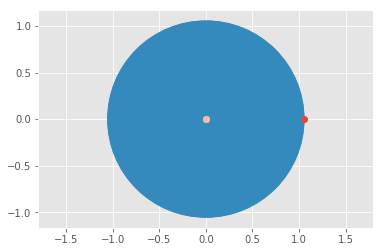

[ 1.05838490e+00+0.00000000e+00j  5.91282418e-04+0.00000000e+00j
  7.65058450e-07+0.00000000e+00j  1.56028864e-09+0.00000000e+00j
  4.22566980e-12+0.00000000e+00j  1.44747339e-14+0.00000000e+00j
  5.82444916e-17+0.00000000e+00j  2.54708315e-19+0.00000000e+00j
  9.24791540e-22+0.00000000e+00j -1.41537859e-22+0.00000000e+00j
  6.78679472e-25+9.60838647e-25j  6.78679472e-25-9.60838647e-25j
  5.06857275e-27+2.80528528e-26j  5.06857275e-27-2.80528528e-26j
 -2.66297697e-28+1.50979306e-28j -2.66297697e-28-1.50979306e-28j
 -3.95330775e-29+0.00000000e+00j  4.52112791e-30+0.00000000e+00j
 -3.37830821e-30+0.00000000e+00j  8.69176656e-34+1.43125199e-33j
  8.69176656e-34-1.43125199e-33j -1.01917418e-34+0.00000000e+00j
  1.46920266e-35+0.00000000e+00j -3.37050857e-36+0.00000000e+00j
 -1.14147311e-37+0.00000000e+00j  2.97461716e-39+1.96249827e-39j
  2.97461716e-39-1.96249827e-39j -1.78693782e-39+0.00000000e+00j
 -7.27507504e-42+5.18520985e-42j -7.27507504e-42-5.18520985e-42j
 -2.29243417e-45+0.000000

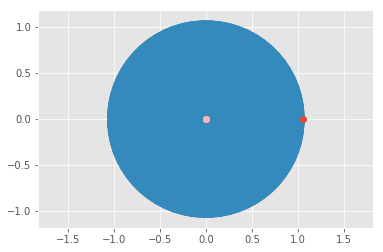

[ 1.06561523e+00+0.00000000e+00j  2.57070286e-04+0.00000000e+00j
  2.30874434e-07+0.00000000e+00j  5.45056608e-10+0.00000000e+00j
  1.56536032e-12+0.00000000e+00j  4.31061288e-15+0.00000000e+00j
  9.87101327e-18+0.00000000e+00j  1.36026162e-20+0.00000000e+00j
 -2.98725343e-23+0.00000000e+00j -3.36356572e-24+0.00000000e+00j
  8.85460374e-26+0.00000000e+00j -1.76695699e-26+0.00000000e+00j
  4.51821947e-27+0.00000000e+00j  9.34288569e-29+0.00000000e+00j
  3.11818092e-30+0.00000000e+00j  1.01550851e-31+7.68381632e-32j
  1.01550851e-31-7.68381632e-32j -4.13562199e-32+0.00000000e+00j
 -1.70206804e-34+0.00000000e+00j -1.83732499e-35+0.00000000e+00j
 -1.99567217e-36+0.00000000e+00j  1.27403467e-38+0.00000000e+00j
 -6.40422835e-41+3.11304707e-40j -6.40422835e-41-3.11304707e-40j
  6.58544625e-42+0.00000000e+00j  2.35345261e-43+0.00000000e+00j
 -1.44251375e-43+1.57162103e-43j -1.44251375e-43-1.57162103e-43j
  6.52823719e-45+3.29321110e-45j  6.52823719e-45-3.29321110e-45j
  6.39750193e-47+1.442254

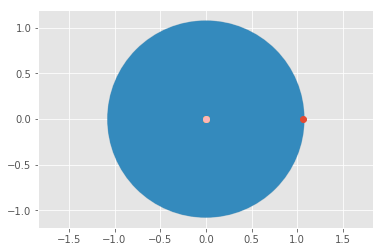

[ 1.02210653e+000+0.00000000e+00j  4.50452317e-004+0.00000000e+00j
  4.16556478e-007+0.00000000e+00j  5.62250074e-010+0.00000000e+00j
  9.01219447e-013+0.00000000e+00j  1.52026645e-015+0.00000000e+00j
  2.56331481e-018+0.00000000e+00j  4.45584063e-021+0.00000000e+00j
  9.19535925e-024+0.00000000e+00j  7.18418973e-026+0.00000000e+00j
  3.30055748e-028+3.87715017e-28j  3.30055748e-028-3.87715017e-28j
 -7.44745228e-030+0.00000000e+00j  4.25106056e-030+0.00000000e+00j
  9.15290286e-031+0.00000000e+00j -1.63644117e-032+0.00000000e+00j
 -1.08072617e-033+0.00000000e+00j  5.47723922e-034+0.00000000e+00j
 -8.28087400e-037+0.00000000e+00j  6.39369966e-038+6.16843092e-38j
  6.39369966e-038-6.16843092e-38j  2.40163695e-041+0.00000000e+00j
  8.96838171e-042+3.90010534e-42j  8.96838171e-042-3.90010534e-42j
 -2.37839625e-043+0.00000000e+00j  4.06121190e-045+0.00000000e+00j
  1.16123296e-046+0.00000000e+00j  1.87127519e-047+0.00000000e+00j
 -4.97408031e-048+0.00000000e+00j -5.68751078e-051+0.00000000e

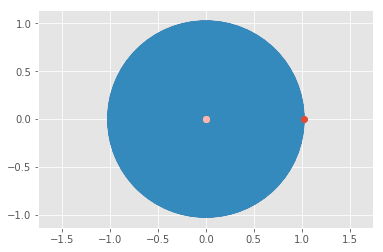

[ 1.05589928e+00+0.00000000e+00j  5.95249002e-04+0.00000000e+00j
  5.92916704e-07+0.00000000e+00j  8.30343883e-10+0.00000000e+00j
  1.42997744e-12+0.00000000e+00j  2.83475412e-15+0.00000000e+00j
  7.00110226e-18+0.00000000e+00j  1.91868125e-20+0.00000000e+00j
  4.23272590e-23+1.71056849e-23j  4.23272590e-23-1.71056849e-23j
  3.42555063e-24+0.00000000e+00j -7.18910297e-25+0.00000000e+00j
  2.55894192e-26+1.43788757e-25j  2.55894192e-26-1.43788757e-25j
 -1.87460320e-27+0.00000000e+00j -8.35683141e-30+2.34255745e-29j
 -8.35683141e-30-2.34255745e-29j -2.32927809e-30+0.00000000e+00j
  1.87706538e-30+0.00000000e+00j -2.59366933e-34+8.15024785e-34j
 -2.59366933e-34-8.15024785e-34j  4.98568029e-35+0.00000000e+00j
  5.56935890e-37+0.00000000e+00j -1.37564994e-38+0.00000000e+00j
  1.08596314e-40+0.00000000e+00j -2.81124585e-41+0.00000000e+00j
 -1.05906396e-42+0.00000000e+00j  3.09451440e-43+0.00000000e+00j
  1.04136498e-44+0.00000000e+00j  3.01856258e-46+0.00000000e+00j
 -1.50798953e-46+0.000000

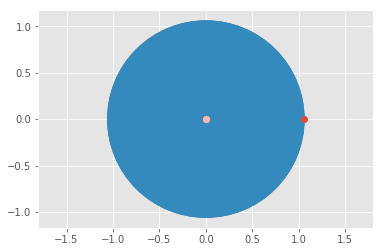

[ 1.02864726e+00+0.00000000e+00j  2.31430490e-04+0.00000000e+00j
  9.78886225e-08+0.00000000e+00j  5.86439852e-11+0.00000000e+00j
  4.43437954e-14+0.00000000e+00j  3.96037598e-17+0.00000000e+00j
  4.10984169e-20+0.00000000e+00j  6.33883433e-23+0.00000000e+00j
  1.09207524e-24+0.00000000e+00j  1.07329716e-25+0.00000000e+00j
 -5.82478095e-27+0.00000000e+00j -4.70933641e-27+0.00000000e+00j
  1.03889373e-29+0.00000000e+00j -1.32298846e-32+4.35629792e-32j
 -1.32298846e-32-4.35629792e-32j -5.91601217e-32+0.00000000e+00j
  3.37528253e-34+0.00000000e+00j -3.20572808e-36+0.00000000e+00j
  9.95454691e-39+1.44517172e-39j  9.95454691e-39-1.44517172e-39j
  3.21320673e-40+0.00000000e+00j -2.86962836e-41+0.00000000e+00j
  1.22254976e-42+0.00000000e+00j  3.09488533e-44+0.00000000e+00j
 -4.51789831e-46+0.00000000e+00j -1.12479632e-47+0.00000000e+00j
  7.02031355e-48+0.00000000e+00j  4.79964783e-50+0.00000000e+00j
  2.85083369e-51+0.00000000e+00j  2.34983272e-53+0.00000000e+00j
  6.65333289e-55+0.000000

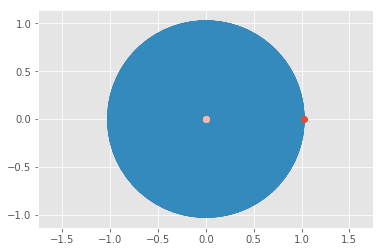

[ 1.06902967e+00+0.00000000e+00j -7.05504544e-05+0.00000000e+00j
  1.49349604e-07+0.00000000e+00j  1.51647757e-10+0.00000000e+00j
  2.55042817e-13+0.00000000e+00j  4.41967651e-16+0.00000000e+00j
  5.77855605e-19+0.00000000e+00j -4.38123992e-21+0.00000000e+00j
  7.44771951e-23+0.00000000e+00j  5.68130346e-25+0.00000000e+00j
  6.19712298e-26+0.00000000e+00j  6.67896092e-27+0.00000000e+00j
 -1.42440215e-27+0.00000000e+00j -4.22109188e-28+0.00000000e+00j
 -1.20377041e-28+0.00000000e+00j  1.20060208e-28+0.00000000e+00j
  1.76035647e-29+2.73984474e-30j  1.76035647e-29-2.73984474e-30j
 -1.21466889e-29+0.00000000e+00j  2.63144924e-30+0.00000000e+00j
 -1.69032258e-31+0.00000000e+00j  2.73744871e-33+0.00000000e+00j
  1.31937173e-35+0.00000000e+00j -1.77442172e-35+0.00000000e+00j
 -6.40415871e-36+0.00000000e+00j  6.82040201e-39+0.00000000e+00j
 -1.22992481e-38+0.00000000e+00j  1.51847766e-43+1.84364093e-41j
  1.51847766e-43-1.84364093e-41j  2.36519936e-44+5.07289409e-44j
  2.36519936e-44-5.072894

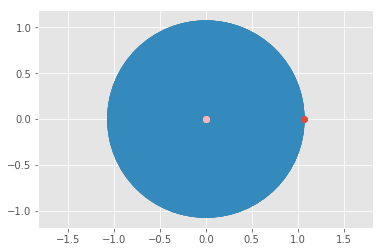

[ 1.03178599e+00+0.00000000e+00j  2.38927316e-04+0.00000000e+00j
  1.30483148e-07+0.00000000e+00j  1.07552972e-10+0.00000000e+00j
  1.18635028e-13+0.00000000e+00j  1.63249304e-16+0.00000000e+00j
  2.44829632e-19+0.00000000e+00j  3.49644205e-22+0.00000000e+00j
 -1.24314873e-23+0.00000000e+00j -5.49218865e-25+0.00000000e+00j
 -7.49626677e-26+0.00000000e+00j  5.24226329e-26+0.00000000e+00j
 -5.32374360e-28+0.00000000e+00j  4.49607016e-29+0.00000000e+00j
  9.23745180e-32+0.00000000e+00j  2.06891622e-33+0.00000000e+00j
 -6.66055773e-35+5.66340806e-35j -6.66055773e-35-5.66340806e-35j
  1.50243159e-37+0.00000000e+00j  3.05829287e-38+0.00000000e+00j
  1.18734070e-40+0.00000000e+00j -4.07007844e-41+0.00000000e+00j
 -8.41907476e-43+0.00000000e+00j  2.97877023e-44+0.00000000e+00j
 -4.13326694e-46+0.00000000e+00j  8.13170440e-47+0.00000000e+00j
  2.01106593e-49+0.00000000e+00j  1.22497106e-50+0.00000000e+00j
 -4.64087772e-53+0.00000000e+00j  3.76464203e-53+0.00000000e+00j
 -5.27930305e-54+0.000000

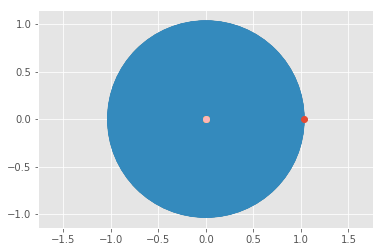

[ 1.00821583e+000+0.00000000e+000j  9.36823845e-005+0.00000000e+000j
  2.35127918e-008+0.00000000e+000j  8.95165879e-012+0.00000000e+000j
  4.78809985e-015+0.00000000e+000j  2.67680189e-018+0.00000000e+000j
  1.12983067e-021+0.00000000e+000j  3.96633690e-025+0.00000000e+000j
  1.01327713e-028+0.00000000e+000j -6.48582275e-030+0.00000000e+000j
  4.12252532e-030+0.00000000e+000j -7.41283384e-034+0.00000000e+000j
 -2.68109298e-033+0.00000000e+000j -1.25283727e-035+0.00000000e+000j
  5.65163631e-037+0.00000000e+000j -4.99583233e-040+0.00000000e+000j
 -3.18897930e-042+0.00000000e+000j -1.46463727e-043+0.00000000e+000j
 -1.10312832e-045+0.00000000e+000j -1.91918908e-048+0.00000000e+000j
 -1.69501562e-049+0.00000000e+000j  4.30337838e-050+0.00000000e+000j
 -5.80526869e-052+0.00000000e+000j  2.88925354e-054+0.00000000e+000j
  1.27790253e-056+0.00000000e+000j  2.79297185e-058+0.00000000e+000j
 -7.90147213e-061+0.00000000e+000j  2.17199586e-064+3.74335745e-063j
  2.17199586e-064-3.74335745e-063j

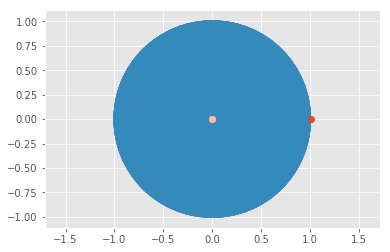

[ 1.00023051e+000+0.00000000e+000j  3.12265736e-006+0.00000000e+000j
  1.69892725e-011+0.00000000e+000j  1.27368138e-016+0.00000000e+000j
  1.31585643e-021+0.00000000e+000j  1.93923335e-026+0.00000000e+000j
  3.82924397e-031+0.00000000e+000j  9.07508136e-036+0.00000000e+000j
  2.63440453e-040+0.00000000e+000j  2.07121787e-044+0.00000000e+000j
 -1.57412573e-050+0.00000000e+000j  2.57263631e-049+0.00000000e+000j
 -1.17028243e-055+0.00000000e+000j  6.03635025e-058+0.00000000e+000j
  1.59495975e-060+0.00000000e+000j -2.22091652e-063+0.00000000e+000j
  2.95527594e-066+0.00000000e+000j  1.07261740e-068+0.00000000e+000j
 -6.23926845e-072+0.00000000e+000j  1.25801788e-075+0.00000000e+000j
 -3.13116391e-078+0.00000000e+000j  2.85985470e-080+0.00000000e+000j
  8.78610484e-084+0.00000000e+000j  7.82390050e-086+0.00000000e+000j
 -2.49626630e-089+0.00000000e+000j -2.05053854e-092+0.00000000e+000j
  2.97560304e-095+0.00000000e+000j  9.84091578e-098+0.00000000e+000j
 -3.39394030e-101+0.00000000e+000j

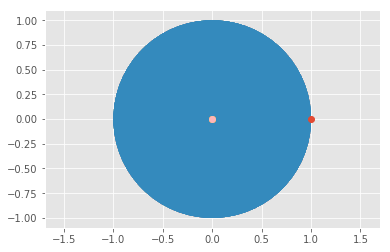

[ 1.03071292e+00+0.00000000e+00j  2.30750449e-04+0.00000000e+00j
  9.97643591e-08+0.00000000e+00j  6.28896149e-11+0.00000000e+00j
  3.24813468e-14+0.00000000e+00j  1.43274823e-17+0.00000000e+00j
  1.05648897e-20+0.00000000e+00j -5.23591922e-25+1.19700142e-24j
 -5.23591922e-25-1.19700142e-24j  2.86859804e-26+0.00000000e+00j
  1.36871108e-27+0.00000000e+00j  5.88702862e-30+7.54597533e-30j
  5.88702862e-30-7.54597533e-30j  2.76557652e-32+1.22304661e-31j
  2.76557652e-32-1.22304661e-31j  3.92098334e-33+0.00000000e+00j
 -1.39045150e-34+0.00000000e+00j  8.09885888e-36+0.00000000e+00j
 -4.34179998e-38+4.88906575e-38j -4.34179998e-38-4.88906575e-38j
 -1.43224404e-39+0.00000000e+00j  6.96100914e-42+0.00000000e+00j
  1.65766404e-42+0.00000000e+00j  4.10809360e-43+0.00000000e+00j
 -1.37303899e-44+0.00000000e+00j  1.05495566e-46+0.00000000e+00j
  1.14223749e-46+0.00000000e+00j -4.50881248e-49+0.00000000e+00j
  1.62186173e-50+0.00000000e+00j -3.98189550e-51+0.00000000e+00j
  3.92495750e-53+0.000000

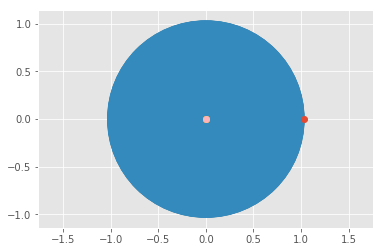

[ 1.46385555e+00+0.00000000e+00j  1.40234537e-02+0.00000000e+00j
  2.47606155e-04+0.00000000e+00j  5.17608183e-06+0.00000000e+00j
  1.42890990e-07+0.00000000e+00j  4.64304050e-09+0.00000000e+00j
  1.40506497e-10+0.00000000e+00j  4.62708514e-12+0.00000000e+00j
  1.97145928e-13+0.00000000e+00j  9.22649703e-15+0.00000000e+00j
  4.30519180e-16+0.00000000e+00j  2.40163051e-17+0.00000000e+00j
  4.16608179e-18+0.00000000e+00j  1.25002084e-18+0.00000000e+00j
 -7.19054744e-19+0.00000000e+00j -1.82478854e-19+0.00000000e+00j
  8.10536595e-20+1.16038275e-20j  8.10536595e-20-1.16038275e-20j
 -7.45381058e-20+0.00000000e+00j -2.73011431e-21+5.78574518e-20j
 -2.73011431e-21-5.78574518e-20j -4.74852747e-20+0.00000000e+00j
  2.34849715e-20+0.00000000e+00j  8.13672213e-21+0.00000000e+00j
  4.80461644e-21+0.00000000e+00j -3.90985753e-21+9.01772764e-22j
 -3.90985753e-21-9.01772764e-22j  9.24422655e-22+2.82464159e-22j
  9.24422655e-22-2.82464159e-22j  2.29804171e-23+2.64510104e-22j
  2.29804171e-23-2.645101

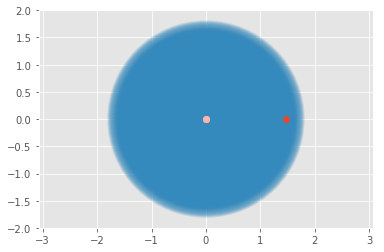

[ 1.97524632e+00+0.00000000e+00j  3.31879260e-02+0.00000000e+00j
  8.82030549e-04+0.00000000e+00j  2.20265139e-05+0.00000000e+00j
  4.04215432e-07+0.00000000e+00j  4.65862991e-09+0.00000000e+00j
  1.14655822e-10+0.00000000e+00j  6.48212366e-12+0.00000000e+00j
  4.68015632e-14+0.00000000e+00j -1.40824760e-14+0.00000000e+00j
  5.97198261e-16+0.00000000e+00j -1.53932552e-17+1.64009903e-17j
 -1.53932552e-17-1.64009903e-17j  1.59458715e-17+0.00000000e+00j
  2.17691692e-19+1.04922545e-17j  2.17691692e-19-1.04922545e-17j
 -1.45951187e-18+2.00177612e-18j -1.45951187e-18-2.00177612e-18j
 -1.36440454e-19+5.68440162e-19j -1.36440454e-19-5.68440162e-19j
 -4.71332388e-19+0.00000000e+00j  1.99270187e-19+3.06601381e-19j
  1.99270187e-19-3.06601381e-19j  1.72459360e-19+0.00000000e+00j
  8.15601704e-20+0.00000000e+00j -5.38783930e-20+4.65259705e-20j
 -5.38783930e-20-4.65259705e-20j  3.62060172e-20+0.00000000e+00j
 -8.58490407e-21+1.60960925e-20j -8.58490407e-21-1.60960925e-20j
 -8.20136068e-22+7.705932

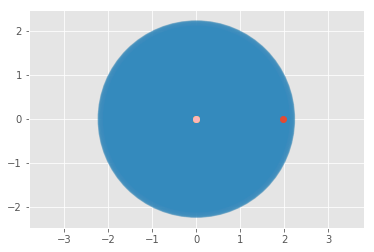

[ 1.00014481e+000+0.j  1.80334280e-006+0.j  9.18739317e-012+0.j
  8.02998553e-017+0.j  8.96172483e-022+0.j  1.05267345e-026+0.j
  1.25276119e-031+0.j  1.54429155e-036+0.j  1.94232291e-041+0.j
  2.51663885e-045+0.j  7.14797501e-049+0.j  2.05784735e-052+0.j
  4.78483428e-056+0.j  1.58078284e-060+0.j -1.74945830e-063+0.j
  1.09908835e-066+0.j -2.89647466e-071+0.j -2.65852043e-073+0.j
  1.02637654e-077+0.j -6.68630377e-080+0.j  4.32807601e-084+0.j
  4.42357402e-090+0.j -1.21243374e-090+0.j -7.15737232e-097+0.j
 -1.40373947e-100+0.j  1.53057903e-108+0.j  1.20859309e-104+0.j
 -4.77860783e-115+0.j -3.50295875e-113+0.j -4.46876260e-119+0.j
 -2.29621686e-123+0.j -1.85434453e-124+0.j -8.31180363e-129+0.j
  2.18050335e-134+0.j  8.53766175e-137+0.j -7.08743929e-141+0.j
 -7.47129283e-146+0.j  3.69729455e-148+0.j -3.80661968e-154+0.j
  3.19558367e-160+0.j -5.95168217e-159+0.j  8.52095265e-163+0.j
  4.44194535e-167+0.j  1.63782880e-168+0.j  5.11404256e-171+0.j
 -3.68189920e-174+0.j  2.13306522e-178+0

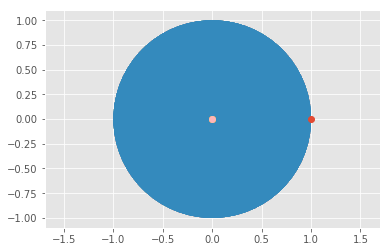

[ 1.05939015e+00+0.00000000e+00j  5.15361289e-04+0.00000000e+00j
  3.12668514e-07+0.00000000e+00j  1.83529162e-10+0.00000000e+00j
  2.51781351e-13+0.00000000e+00j  5.95785608e-16+0.00000000e+00j
  1.35640699e-18+0.00000000e+00j  3.16758275e-21+0.00000000e+00j
  4.75378201e-22+0.00000000e+00j -5.10380702e-24+0.00000000e+00j
  1.07143955e-24+0.00000000e+00j -9.08098993e-25+4.46876307e-25j
 -9.08098993e-25-4.46876307e-25j  1.06894238e-26+0.00000000e+00j
 -8.53887416e-27+3.78924332e-27j -8.53887416e-27-3.78924332e-27j
  1.67397126e-27+7.37088865e-27j  1.67397126e-27-7.37088865e-27j
  1.30342042e-27+0.00000000e+00j -7.41783211e-28+0.00000000e+00j
 -3.33415394e-30+0.00000000e+00j  5.38060925e-30+0.00000000e+00j
 -1.30273538e-32+0.00000000e+00j  5.20236029e-33+0.00000000e+00j
 -1.37950256e-33+0.00000000e+00j  1.46578357e-34+0.00000000e+00j
 -3.82090695e-36+0.00000000e+00j -5.00770089e-38+1.85565445e-37j
 -5.00770089e-38-1.85565445e-37j -3.04040223e-38+0.00000000e+00j
 -2.04459863e-39+0.000000

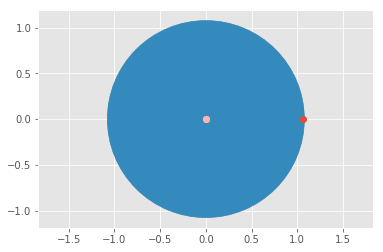

[ 1.07200460e+00+0.00000000e+00j  3.61451214e-04+0.00000000e+00j
  1.52002368e-07+0.00000000e+00j  9.19112207e-11+0.00000000e+00j
  8.17718474e-14+0.00000000e+00j  1.21843031e-16+0.00000000e+00j
  2.38644792e-19+0.00000000e+00j  3.98993860e-21+0.00000000e+00j
  7.50627157e-23+0.00000000e+00j  4.95911839e-23+0.00000000e+00j
  4.14824695e-25+3.03990142e-25j  4.14824695e-25-3.03990142e-25j
 -4.84580611e-26+0.00000000e+00j  2.33682511e-26+0.00000000e+00j
  2.14228462e-27+3.29170417e-27j  2.14228462e-27-3.29170417e-27j
  3.42119442e-28+0.00000000e+00j  3.42275246e-29+0.00000000e+00j
  2.01757307e-29+0.00000000e+00j -6.58248533e-32+0.00000000e+00j
  1.41142794e-31+0.00000000e+00j -3.93836239e-34+0.00000000e+00j
  7.76176961e-36+0.00000000e+00j -1.18760165e-36+0.00000000e+00j
  2.62874224e-37+0.00000000e+00j  5.83326262e-40+0.00000000e+00j
 -4.61993239e-41+0.00000000e+00j  7.41457192e-42+0.00000000e+00j
 -4.77790110e-43+0.00000000e+00j  5.61422237e-45+0.00000000e+00j
 -1.36823956e-46+0.000000

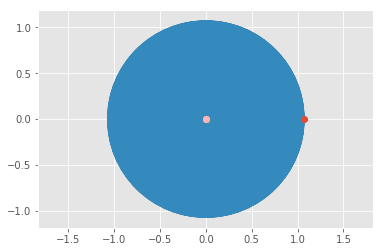

[ 1.00118224e+000+0.00000000e+000j  2.33183099e-005+0.00000000e+000j
  1.03676341e-009+0.00000000e+000j  6.71163884e-014+0.00000000e+000j
  6.07151430e-018+0.00000000e+000j  6.70784604e-022+0.00000000e+000j
  8.78137053e-026+0.00000000e+000j  1.23068828e-029+0.00000000e+000j
  1.38206344e-033+0.00000000e+000j -1.05633665e-037+0.00000000e+000j
  6.91170526e-040+0.00000000e+000j  1.60021517e-042+0.00000000e+000j
  3.39616178e-046+0.00000000e+000j -1.69987213e-045+0.00000000e+000j
  6.80107902e-050+0.00000000e+000j  1.26029818e-052+0.00000000e+000j
 -1.91500411e-055+0.00000000e+000j -2.73997262e-058+0.00000000e+000j
  5.43636030e-061+0.00000000e+000j -2.53816973e-062+0.00000000e+000j
 -8.66290637e-066+0.00000000e+000j -1.06918693e-068+0.00000000e+000j
 -9.54762733e-071+0.00000000e+000j -4.80589289e-073+0.00000000e+000j
  1.18858913e-075+0.00000000e+000j -8.30784380e-079+0.00000000e+000j
 -1.38718226e-080+0.00000000e+000j  7.72651456e-083+0.00000000e+000j
 -8.35903389e-086+0.00000000e+000j

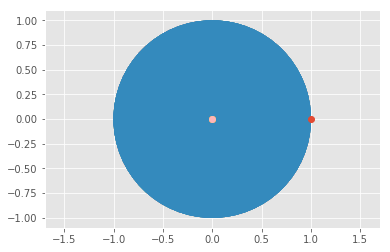

[ 1.01939199e+00+0.00000000e+00j -2.56317106e-05+0.00000000e+00j
  6.27708123e-09+0.00000000e+00j  3.26436700e-12+0.00000000e+00j
  1.45368070e-15+0.00000000e+00j  5.26052947e-19+0.00000000e+00j
  3.06318453e-22+0.00000000e+00j  8.79380017e-25+0.00000000e+00j
 -1.64971397e-25+0.00000000e+00j  9.82480953e-28+1.45725997e-26j
  9.82480953e-28-1.45725997e-26j -3.62008602e-27+0.00000000e+00j
  1.81847153e-27+0.00000000e+00j -1.39283765e-28+0.00000000e+00j
  2.51889189e-30+3.34123132e-30j  2.51889189e-30-3.34123132e-30j
  3.37346665e-31+0.00000000e+00j  4.36461533e-33+0.00000000e+00j
 -7.35433629e-34+0.00000000e+00j -1.04418906e-34+0.00000000e+00j
 -9.57293490e-37+0.00000000e+00j -8.85886545e-39+0.00000000e+00j
 -8.42674203e-42+2.30420639e-41j -8.42674203e-42-2.30420639e-41j
  6.27348194e-44+0.00000000e+00j -6.44248050e-45+0.00000000e+00j
  7.09635522e-48+0.00000000e+00j -2.28031632e-50+0.00000000e+00j
 -1.13778980e-51+0.00000000e+00j  3.08687283e-53+0.00000000e+00j
  4.81693776e-56+0.000000

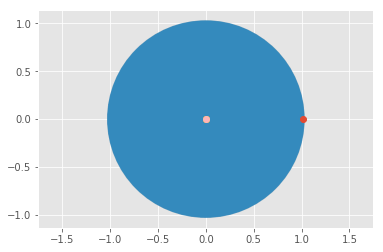

[ 1.51242059e+00+0.00000000e+00j  8.37051509e-03+0.00000000e+00j
  1.07613465e-04+0.00000000e+00j  1.79436849e-06+0.00000000e+00j
  3.79826265e-08+0.00000000e+00j  9.78643418e-10+0.00000000e+00j
  2.28533280e-11+0.00000000e+00j  4.92484679e-13+0.00000000e+00j
  9.31983549e-15+0.00000000e+00j  1.54374877e-16+0.00000000e+00j
  4.25615988e-18+0.00000000e+00j  1.84740167e-18+0.00000000e+00j
 -5.52298083e-19+2.75737682e-19j -5.52298083e-19-2.75737682e-19j
  5.90500399e-19+0.00000000e+00j  5.62775146e-20+7.78488124e-20j
  5.62775146e-20-7.78488124e-20j -3.50187193e-20+0.00000000e+00j
  1.78549127e-20+0.00000000e+00j -6.63273496e-21+0.00000000e+00j
  2.03663452e-21+0.00000000e+00j  2.89984369e-22+0.00000000e+00j
  8.77575970e-23+7.26576249e-23j  8.77575970e-23-7.26576249e-23j
 -2.38053671e-23+7.84648384e-24j -2.38053671e-23-7.84648384e-24j
  2.39647360e-23+0.00000000e+00j  2.08901720e-24+0.00000000e+00j
  4.13542215e-25+5.40950387e-25j  4.13542215e-25-5.40950387e-25j
  1.86141662e-25+0.000000

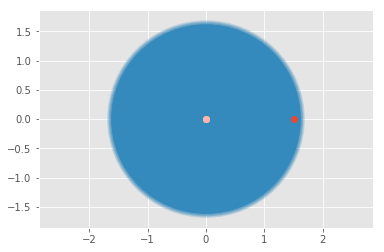

[ 1.01447413e+000+0.00000000e+00j  2.22142293e-004+0.00000000e+00j
  8.54439845e-008+0.00000000e+00j  5.18702016e-011+0.00000000e+00j
  4.03376077e-014+0.00000000e+00j  2.69886861e-017+0.00000000e+00j
  1.38255773e-020+0.00000000e+00j  1.08327067e-023+0.00000000e+00j
  1.17684751e-026+0.00000000e+00j  1.57468310e-028+0.00000000e+00j
 -1.14488066e-030+0.00000000e+00j  1.52152285e-031+0.00000000e+00j
  3.98817525e-032+0.00000000e+00j  7.86074705e-034+0.00000000e+00j
 -6.00459533e-035+0.00000000e+00j  3.99038957e-036+0.00000000e+00j
  2.94146428e-038+0.00000000e+00j -1.09606112e-040+0.00000000e+00j
 -7.80506495e-042+0.00000000e+00j  5.09442884e-043+0.00000000e+00j
 -2.66429617e-046+0.00000000e+00j  1.09488889e-045+0.00000000e+00j
  7.60317021e-050+0.00000000e+00j  2.89616899e-049+0.00000000e+00j
  1.10127697e-051+0.00000000e+00j  7.77135408e-054+0.00000000e+00j
 -9.74411132e-054+0.00000000e+00j  2.32018964e-056+0.00000000e+00j
  8.00124735e-057+0.00000000e+00j  1.40751359e-059+0.00000000e

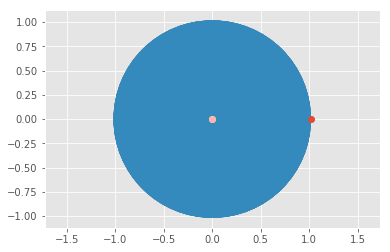

[ 1.00011101e+000+0.j  2.62383289e-006+0.j  1.45181454e-011+0.j
  1.30199037e-016+0.j  1.70124213e-021+0.j  3.08191493e-026+0.j
  7.43764040e-031+0.j  2.22472982e-035+0.j  7.41066449e-040+0.j
  2.38906606e-044+0.j -4.24712673e-050+0.j  1.48338280e-051+0.j
  5.87093182e-053+0.j  2.62780694e-062+0.j  4.85483272e-058+0.j
 -1.39525174e-066+0.j  1.41076129e-066+0.j -5.34065957e-074+0.j
  9.18712390e-072+0.j  1.04275415e-078+0.j  8.86740449e-081+0.j
  1.26701493e-085+0.j -1.70174366e-088+0.j  5.63156464e-096+0.j
 -4.75987424e-094+0.j  1.88174787e-100+0.j -2.68480643e-104+0.j
 -7.79183762e-108+0.j  1.23063322e-113+0.j -2.00249031e-114+0.j
 -1.14676422e-118+0.j  6.31219193e-122+0.j -6.47062891e-129+0.j
  3.80499174e-127+0.j  5.81229863e-133+0.j  6.55009312e-137+0.j
  4.17885297e-140+0.j  1.84301513e-144+0.j  2.15222822e-147+0.j
 -1.33685049e-151+0.j -2.01474466e-155+0.j  3.33390459e-159+0.j
 -1.83529850e-163+0.j  6.66368571e-169+0.j -3.80909573e-169+0.j
  2.23042506e-174+0.j  3.40032077e-178+0

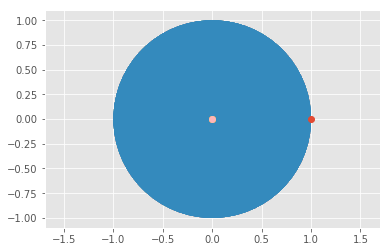

[ 1.01904882e+000+0.00000000e+00j  3.19060316e-004+0.00000000e+00j
  1.65974053e-007+0.00000000e+00j  1.13596367e-010+0.00000000e+00j
  1.11358142e-013+0.00000000e+00j  1.39586541e-016+0.00000000e+00j
  2.08660386e-019+0.00000000e+00j  3.33004099e-022+0.00000000e+00j
  4.24496330e-025+0.00000000e+00j -1.80065052e-026+0.00000000e+00j
 -5.83394680e-028+0.00000000e+00j -6.96083588e-029+0.00000000e+00j
 -2.94329457e-030+0.00000000e+00j  1.50158638e-031+0.00000000e+00j
 -4.06787117e-033+0.00000000e+00j  3.73822315e-035+0.00000000e+00j
  9.43246520e-037+0.00000000e+00j -3.33372850e-038+0.00000000e+00j
  2.50725941e-039+0.00000000e+00j  1.70237144e-041+0.00000000e+00j
  3.76587538e-042+0.00000000e+00j  3.46448499e-044+0.00000000e+00j
  2.31105593e-046+0.00000000e+00j  4.99721204e-048+1.86142468e-48j
  4.99721204e-048-1.86142468e-48j -3.43951030e-049+0.00000000e+00j
  2.34879607e-050+0.00000000e+00j  1.02850815e-052+7.27045557e-53j
  1.02850815e-052-7.27045557e-53j -3.84960715e-055+0.00000000e

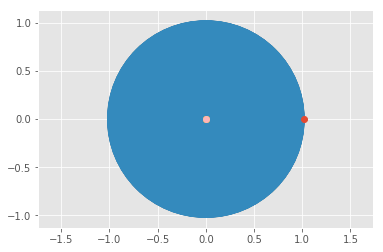

[ 1.00211610e+000+0.00000000e+000j  1.94889267e-005+0.00000000e+000j
  1.20691965e-009+0.00000000e+000j  7.63220430e-014+0.00000000e+000j
  8.01714741e-018+0.00000000e+000j  1.04251551e-021+0.00000000e+000j
  5.89447316e-026+0.00000000e+000j  8.10036875e-031+0.00000000e+000j
 -1.46790100e-033+0.00000000e+000j -4.77260815e-036+0.00000000e+000j
 -5.41666497e-040+0.00000000e+000j  7.54476807e-039+0.00000000e+000j
  6.75555972e-041+0.00000000e+000j  6.05408491e-043+0.00000000e+000j
 -1.05287010e-044+0.00000000e+000j  1.56953253e-045+0.00000000e+000j
  4.18567776e-050+0.00000000e+000j  1.81750630e-053+0.00000000e+000j
  3.13283320e-056+0.00000000e+000j -1.71395502e-059+0.00000000e+000j
  6.02207774e-062+0.00000000e+000j  3.44093576e-064+0.00000000e+000j
 -3.63501041e-068+0.00000000e+000j -7.85013499e-070+0.00000000e+000j
  1.67016958e-071+0.00000000e+000j  2.14553236e-075+0.00000000e+000j
  1.58904813e-077+0.00000000e+000j  2.68412816e-078+0.00000000e+000j
  3.25840923e-081+0.00000000e+000j

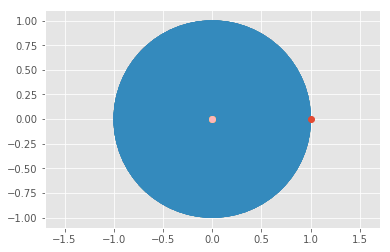

[ 1.01011450e+000+0.00000000e+00j  1.31724995e-004+0.00000000e+00j
  3.57251790e-008+0.00000000e+00j  1.57402843e-011+0.00000000e+00j
  1.03819563e-014+0.00000000e+00j  9.72614953e-018+0.00000000e+00j
  1.23857113e-020+0.00000000e+00j  1.90137590e-023+0.00000000e+00j
  2.73591798e-026+0.00000000e+00j -3.09496637e-028+0.00000000e+00j
  6.16427847e-030+0.00000000e+00j  2.33417266e-031+0.00000000e+00j
  5.93926240e-033+0.00000000e+00j  3.40693776e-036+2.97125450e-36j
  3.40693776e-036-2.97125450e-36j -5.29775392e-037+0.00000000e+00j
  2.33760647e-038+0.00000000e+00j -3.67527208e-041+0.00000000e+00j
 -5.24098024e-042+0.00000000e+00j -5.26093365e-044+0.00000000e+00j
 -1.86654271e-045+0.00000000e+00j  1.94662832e-047+0.00000000e+00j
  5.28797840e-050+0.00000000e+00j  1.32961938e-052+0.00000000e+00j
 -8.05298115e-054+0.00000000e+00j  1.44015519e-056+0.00000000e+00j
 -2.36950387e-060+3.47252464e-60j -2.36950387e-060-3.47252464e-60j
  1.02803399e-064+5.23255178e-64j  1.02803399e-064-5.23255178e

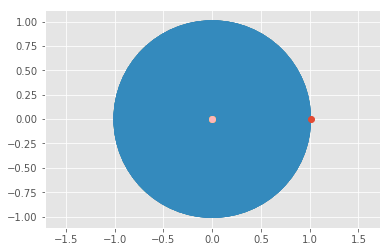

[ 1.00220101e+000+0.00000000e+00j -8.80226634e-006+0.00000000e+00j
  1.63586804e-010+0.00000000e+00j -4.49891863e-015+0.00000000e+00j
  1.66292309e-019+0.00000000e+00j -3.54951434e-023+0.00000000e+00j
  1.30120276e-026+0.00000000e+00j -2.00450861e-028+0.00000000e+00j
  1.19455025e-030+0.00000000e+00j -7.53792076e-033+0.00000000e+00j
 -1.62874701e-036+0.00000000e+00j  6.43362900e-038+0.00000000e+00j
  4.32205671e-042+0.00000000e+00j -6.45582975e-046+0.00000000e+00j
 -5.09842360e-047+0.00000000e+00j  4.64974154e-050+0.00000000e+00j
 -5.02599439e-055+0.00000000e+00j  8.07110698e-055+0.00000000e+00j
  4.96834272e-058+0.00000000e+00j  2.47121336e-061+0.00000000e+00j
 -1.12787087e-063+0.00000000e+00j  8.54774632e-067+0.00000000e+00j
  2.60522797e-068+0.00000000e+00j -2.15995513e-070+0.00000000e+00j
 -3.33763588e-073+0.00000000e+00j  2.30482598e-074+0.00000000e+00j
 -2.24287887e-075+0.00000000e+00j  4.93229780e-079+0.00000000e+00j
  2.24062922e-082+0.00000000e+00j -1.15975062e-081+0.00000000e

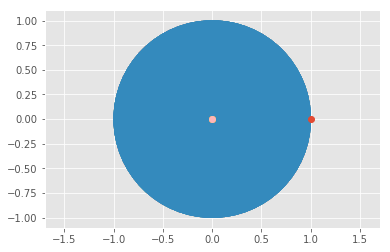

[ 1.01741476e+000+0.00000000e+00j  4.31933252e-004+0.00000000e+00j
  3.48613094e-007+0.00000000e+00j  3.96737491e-010+0.00000000e+00j
  5.38502951e-013+0.00000000e+00j  8.55536558e-016+0.00000000e+00j
  1.48360985e-018+0.00000000e+00j  2.74551802e-021+0.00000000e+00j
  5.69049261e-024+0.00000000e+00j  1.38854046e-026+0.00000000e+00j
  4.78245533e-029+0.00000000e+00j -6.04207460e-029+0.00000000e+00j
 -2.98423495e-031+0.00000000e+00j  4.20474671e-031+0.00000000e+00j
  6.62941239e-034+8.03178819e-33j  6.62941239e-034-8.03178819e-33j
 -4.25533942e-035+0.00000000e+00j -1.43730094e-037+1.14182138e-37j
 -1.43730094e-037-1.14182138e-37j -2.57842019e-039+0.00000000e+00j
 -1.59052142e-041+0.00000000e+00j  4.21450624e-042+0.00000000e+00j
 -6.70865700e-044+0.00000000e+00j -2.68990785e-045+0.00000000e+00j
  3.49204619e-046+0.00000000e+00j  8.91717221e-049+0.00000000e+00j
 -5.54649915e-050+0.00000000e+00j  3.25828727e-053+0.00000000e+00j
  3.40324189e-054+0.00000000e+00j -1.19186377e-055+0.00000000e

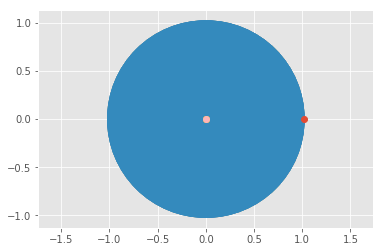

[ 1.00015104e+000+0.j  2.40855055e-006+0.j  6.11937268e-012+0.j
  9.86506059e-018+0.j  9.03355328e-024+0.j  6.79152832e-030+0.j
  2.32571576e-036+0.j  4.22459479e-041+0.j  3.59939883e-047+0.j
 -2.95925590e-045+0.j -5.24011480e-049+0.j  1.72327802e-049+0.j
 -3.94601475e-051+0.j  7.55378205e-054+0.j -8.29350125e-058+0.j
  1.34601750e-058+0.j  4.86067025e-063+0.j  1.96701040e-066+0.j
  1.46894335e-070+0.j  2.04322282e-075+0.j -1.50753866e-075+0.j
 -3.77973274e-080+0.j  1.48701031e-084+0.j -3.24816226e-086+0.j
  6.75252190e-090+0.j -5.96856542e-094+0.j -2.17079324e-102+0.j
 -3.20436189e-098+0.j -1.52927768e-106+0.j  1.94264104e-110+0.j
  4.61923517e-114+0.j  7.34383887e-122+0.j  3.70837136e-119+0.j
 -3.40233272e-125+0.j -3.84171106e-128+0.j  8.86513084e-133+0.j
 -1.05603944e-136+0.j -1.27217824e-141+0.j  2.58368671e-148+0.j
  8.17656758e-147+0.j  2.82184490e-157+0.j  9.52277012e-154+0.j
  1.87616968e-162+0.j  9.76242919e-164+0.j -6.15832954e-169+0.j
  3.06700869e-169+0.j  4.69329876e-174+0

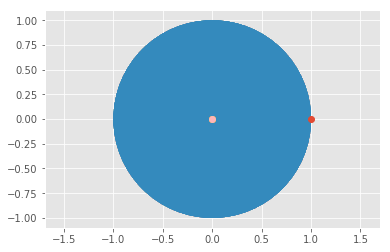

[ 1.00324282e+000+0.00000000e+000j  7.17688431e-005+0.00000000e+000j
  1.15259203e-008+0.00000000e+000j  2.44201532e-012+0.00000000e+000j
  4.13211741e-016+0.00000000e+000j  3.04843666e-020+0.00000000e+000j
  1.75424618e-026+0.00000000e+000j  2.34282096e-030+0.00000000e+000j
 -1.38304762e-032+0.00000000e+000j -2.30816142e-036+0.00000000e+000j
 -4.25701816e-038+0.00000000e+000j  5.88352229e-041+2.35592842e-040j
  5.88352229e-041-2.35592842e-040j -3.59457066e-043+0.00000000e+000j
  1.58877520e-042+0.00000000e+000j -2.66544646e-044+0.00000000e+000j
  1.45662681e-044+0.00000000e+000j -1.54205543e-047+0.00000000e+000j
 -2.88646179e-049+0.00000000e+000j -5.02582499e-053+0.00000000e+000j
  1.17464107e-052+0.00000000e+000j -1.26784069e-056+0.00000000e+000j
 -2.78817209e-057+0.00000000e+000j -5.14882689e-060+0.00000000e+000j
 -2.37350995e-062+0.00000000e+000j -1.07257408e-064+0.00000000e+000j
 -4.43366425e-069+0.00000000e+000j  1.09768665e-071+0.00000000e+000j
  3.10597004e-074+0.00000000e+000j

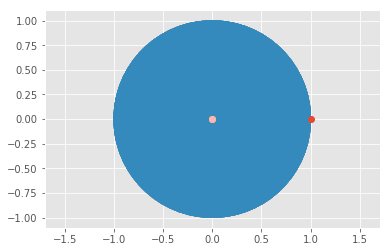

[ 1.08382192e+00+0.00000000e+00j  1.32387868e-03+0.00000000e+00j
  3.55920752e-06+0.00000000e+00j  1.39059364e-08+0.00000000e+00j
  7.11571795e-11+0.00000000e+00j  4.12444494e-13+0.00000000e+00j
  2.90937575e-15+0.00000000e+00j  2.44775456e-17+0.00000000e+00j
  2.08596353e-19+0.00000000e+00j  3.81738085e-21+0.00000000e+00j
  3.57364824e-22+0.00000000e+00j -1.19360892e-22+0.00000000e+00j
 -7.33754462e-24+5.91011114e-24j -7.33754462e-24-5.91011114e-24j
  1.24729689e-25+0.00000000e+00j -4.52995599e-27+1.11092855e-26j
 -4.52995599e-27-1.11092855e-26j  6.56629261e-27+0.00000000e+00j
  7.35480000e-28+0.00000000e+00j -3.36751861e-30+0.00000000e+00j
  3.43196773e-31+0.00000000e+00j  3.92793734e-32+0.00000000e+00j
 -1.02944916e-32+0.00000000e+00j  5.03417089e-33+0.00000000e+00j
 -6.96309422e-34+0.00000000e+00j  2.46521453e-36+2.27489370e-36j
  2.46521453e-36-2.27489370e-36j -2.85665033e-37+0.00000000e+00j
  7.73299265e-39+0.00000000e+00j  1.31144868e-39+3.47418511e-39j
  1.31144868e-39-3.474185

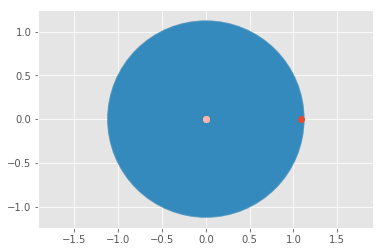

[ 1.02468484e+00+0.00000000e+00j  2.06924011e-04+0.00000000e+00j
  8.51715877e-08+0.00000000e+00j  4.86646398e-11+0.00000000e+00j
  3.88392163e-14+0.00000000e+00j  4.19470435e-17+0.00000000e+00j
  5.85076671e-20+0.00000000e+00j  9.84223848e-23+0.00000000e+00j
  7.93499534e-26+7.81831443e-26j  7.93499534e-26-7.81831443e-26j
 -5.65195543e-28+3.61851230e-27j -5.65195543e-28-3.61851230e-27j
  6.26151799e-28+0.00000000e+00j  3.61775194e-29+0.00000000e+00j
 -1.55443559e-31+0.00000000e+00j -1.12904267e-32+0.00000000e+00j
  6.11691979e-34+0.00000000e+00j  7.10386062e-36+0.00000000e+00j
 -3.49886547e-37+0.00000000e+00j -1.60347162e-38+0.00000000e+00j
  2.20388244e-40+0.00000000e+00j -2.27390785e-41+0.00000000e+00j
 -4.31819786e-43+0.00000000e+00j  6.51467744e-46+1.87973342e-45j
  6.51467744e-46-1.87973342e-45j  9.13349349e-48+0.00000000e+00j
 -1.67380029e-49+0.00000000e+00j -3.04468179e-51+0.00000000e+00j
  2.72814146e-53+6.58959407e-53j  2.72814146e-53-6.58959407e-53j
  4.25284396e-53+0.000000

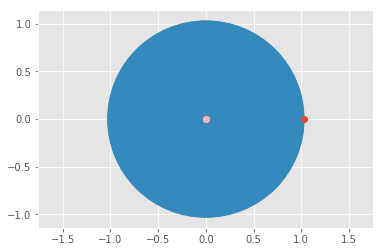

[ 1.24982153e+00+0.00000000e+00j  4.49266834e-03+0.00000000e+00j
  3.70343467e-05+0.00000000e+00j  3.67661409e-07+0.00000000e+00j
  4.51799319e-09+0.00000000e+00j  5.73249433e-11+0.00000000e+00j
  1.02304249e-12+0.00000000e+00j  2.50950901e-14+0.00000000e+00j
  6.42674123e-16+0.00000000e+00j  2.00865401e-17+0.00000000e+00j
  9.78948593e-19+0.00000000e+00j  1.82828353e-19+0.00000000e+00j
  2.87033024e-20+0.00000000e+00j -3.73556315e-22+1.10622975e-20j
 -3.73556315e-22-1.10622975e-20j  4.11455408e-21+0.00000000e+00j
  5.70338266e-22+4.47074768e-22j  5.70338266e-22-4.47074768e-22j
 -6.07602573e-22+0.00000000e+00j  2.70935857e-23+2.01829042e-22j
  2.70935857e-23-2.01829042e-22j  5.33409954e-23+0.00000000e+00j
  7.39923578e-25+2.15309466e-23j  7.39923578e-25-2.15309466e-23j
  1.15579417e-23+0.00000000e+00j -2.73315263e-24+2.21298760e-24j
 -2.73315263e-24-2.21298760e-24j  5.96987527e-25+0.00000000e+00j
  2.21366822e-26+3.31630408e-26j  2.21366822e-26-3.31630408e-26j
 -2.76165315e-27+0.000000

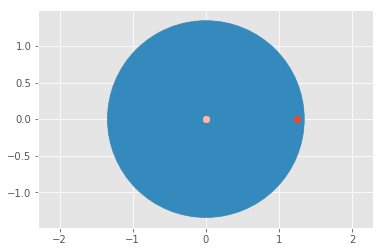

[ 1.06338002e+00+0.00000000e+00j  5.70555012e-04+0.00000000e+00j
  4.50148175e-07+0.00000000e+00j  1.76383647e-10+0.00000000e+00j
  5.62874527e-15+0.00000000e+00j -1.12212533e-17+0.00000000e+00j
 -2.24325845e-20+0.00000000e+00j -1.15787563e-22+7.84449273e-23j
 -1.15787563e-22-7.84449273e-23j  8.97798755e-23+0.00000000e+00j
 -4.15008088e-23+0.00000000e+00j -1.27239200e-24+0.00000000e+00j
  4.85106943e-25+0.00000000e+00j -3.45682129e-26+0.00000000e+00j
  1.63494455e-26+0.00000000e+00j -1.28970597e-27+0.00000000e+00j
 -2.75862907e-28+0.00000000e+00j  7.79499547e-29+0.00000000e+00j
 -3.23126975e-29+0.00000000e+00j -1.15794837e-30+0.00000000e+00j
 -1.18409113e-31+0.00000000e+00j  1.12903660e-31+0.00000000e+00j
 -5.70240307e-35+3.34121758e-34j -5.70240307e-35-3.34121758e-34j
 -2.26324864e-37+4.69199623e-37j -2.26324864e-37-4.69199623e-37j
 -2.71612116e-39+0.00000000e+00j  9.94147950e-41+0.00000000e+00j
  1.41319039e-41+0.00000000e+00j  1.14521757e-42+0.00000000e+00j
  7.48026974e-45+0.000000

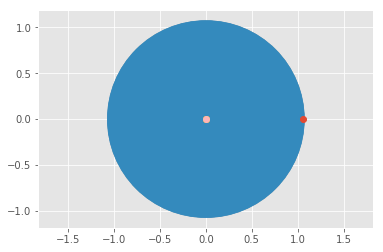

[ 1.83112240e+01+0.00000000e+00j  6.02429931e+00+0.00000000e+00j
  1.03739637e+00+0.00000000e+00j -5.51666856e-01+0.00000000e+00j
  8.40377897e-02+0.00000000e+00j  6.00704055e-03+0.00000000e+00j
  9.40632720e-04+0.00000000e+00j  7.23211622e-05+0.00000000e+00j
  6.11403498e-06+0.00000000e+00j  8.80370865e-07+0.00000000e+00j
  5.86954870e-08+0.00000000e+00j  2.26330095e-09+0.00000000e+00j
  2.67937480e-11+0.00000000e+00j -1.92224546e-11+0.00000000e+00j
  2.17369557e-13+0.00000000e+00j  6.46633061e-14+0.00000000e+00j
 -9.40375198e-15+0.00000000e+00j -2.76011641e-15+0.00000000e+00j
 -1.74673820e-15+7.94990617e-16j -1.74673820e-15-7.94990617e-16j
  7.82004886e-16+1.38145171e-15j  7.82004886e-16-1.38145171e-15j
  1.65985213e-15+0.00000000e+00j -5.12952397e-17+1.18486917e-15j
 -5.12952397e-17-1.18486917e-15j -3.37599912e-16+1.09334883e-15j
 -3.37599912e-16-1.09334883e-15j  7.60015644e-16+8.63251051e-16j
  7.60015644e-16-8.63251051e-16j  1.02450128e-15+4.38184060e-16j
  1.02450128e-15-4.381840

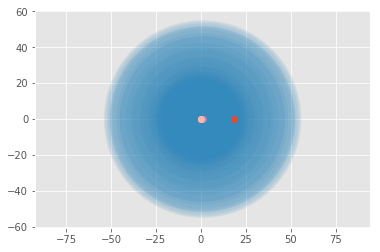

[ 1.00010354e+000+0.00000000e+00j  2.65068591e-006+0.00000000e+00j
  1.49183918e-011+0.00000000e+00j  1.29325610e-016+0.00000000e+00j
  1.45877606e-021+0.00000000e+00j  1.94309640e-026+0.00000000e+00j
  3.00363833e-031+0.00000000e+00j  5.17022346e-036+0.00000000e+00j
  8.45806841e-041+0.00000000e+00j  1.27859829e-045+0.00000000e+00j
  7.09261011e-050+0.00000000e+00j  4.37817624e-055+0.00000000e+00j
 -6.29317916e-058+0.00000000e+00j -1.13868679e-061+0.00000000e+00j
  1.46698131e-065+0.00000000e+00j -2.98936360e-069+0.00000000e+00j
  1.16926856e-073+0.00000000e+00j -2.13711970e-076+2.00620355e-76j
 -2.13711970e-076-2.00620355e-76j -1.30667188e-081+0.00000000e+00j
 -5.55116453e-085+0.00000000e+00j  1.22638613e-088+0.00000000e+00j
  1.00032399e-092+0.00000000e+00j -4.35655688e-097+0.00000000e+00j
  6.42643945e-099+0.00000000e+00j  4.09134333e-104+0.00000000e+00j
 -1.41925932e-106+0.00000000e+00j  1.13690973e-110+0.00000000e+00j
  5.56200147e-118+0.00000000e+00j  2.15077237e-114+0.00000000e

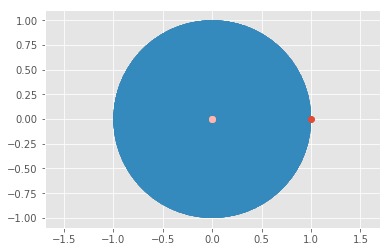

[ 1.00010354e+00+0.00000000e+00j  2.65068591e-06+0.00000000e+00j
  1.49183918e-11+0.00000000e+00j  1.29325610e-16+0.00000000e+00j
  1.45877606e-21+0.00000000e+00j  1.94309633e-26+0.00000000e+00j
  3.00363010e-31+0.00000000e+00j  5.16924399e-36+0.00000000e+00j
  1.80260548e-39+0.00000000e+00j  8.37515282e-41+0.00000000e+00j
  2.12985786e-43+0.00000000e+00j  9.83577888e-46+0.00000000e+00j
  3.17925732e-46+0.00000000e+00j  4.36368511e-49+0.00000000e+00j
  4.65222539e-50+0.00000000e+00j  1.12458691e-52+1.11340618e-52j
  1.12458691e-52-1.11340618e-52j  1.62074927e-53+0.00000000e+00j
  2.44232085e-55+9.12478974e-55j  2.44232085e-55-9.12478974e-55j
 -5.54104622e-55+3.41411269e-55j -5.54104622e-55-3.41411269e-55j
 -3.61084582e-55+0.00000000e+00j  1.94293833e-55+0.00000000e+00j
 -8.45355966e-56+1.53044891e-56j -8.45355966e-56-1.53044891e-56j
 -2.13031837e-57+8.86234506e-56j -2.13031837e-57-8.86234506e-56j
  2.81889548e-56+7.20336902e-56j  2.81889548e-56-7.20336902e-56j
  3.97704518e-56+3.289957

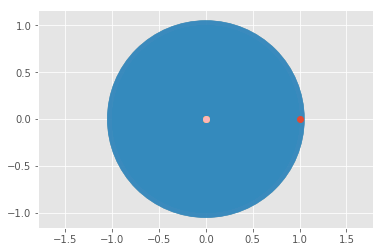

[ 1.02815370e+00+0.00000000e+00j  8.73810177e-04+0.00000000e+00j
  4.08126149e-07+0.00000000e+00j  3.18459742e-10+0.00000000e+00j
  3.64651896e-13+0.00000000e+00j  4.90759718e-16+0.00000000e+00j
  7.07359368e-19+0.00000000e+00j  1.03870382e-21+0.00000000e+00j
  4.74438198e-25+0.00000000e+00j -6.62510171e-25+0.00000000e+00j
  3.63991230e-27+0.00000000e+00j -4.52844348e-28+0.00000000e+00j
  1.57717570e-28+0.00000000e+00j  7.93650934e-29+0.00000000e+00j
 -1.30927418e-31+0.00000000e+00j -1.99490591e-33+9.38791304e-33j
 -1.99490591e-33-9.38791304e-33j -6.93291645e-34+0.00000000e+00j
  6.81586074e-36+0.00000000e+00j -1.33134843e-37+3.17638781e-37j
 -1.33134843e-37-3.17638781e-37j  9.87139302e-40+0.00000000e+00j
 -1.21971709e-39+0.00000000e+00j  1.69506818e-41+0.00000000e+00j
 -1.95125043e-42+0.00000000e+00j  4.75856066e-44+0.00000000e+00j
 -7.50615879e-46+0.00000000e+00j  1.68632039e-47+0.00000000e+00j
  2.42746119e-49+0.00000000e+00j -1.76062708e-50+0.00000000e+00j
  1.50430191e-52+0.000000

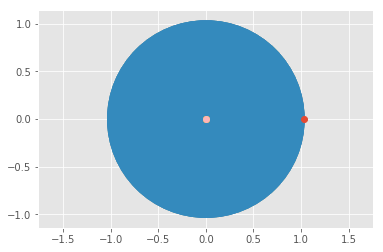

[ 1.01077346e+000+0.00000000e+000j  6.53943830e-005+0.00000000e+000j
  8.89977375e-009+0.00000000e+000j  3.28303312e-012+0.00000000e+000j
  1.82894757e-015+0.00000000e+000j  1.53596058e-018+0.00000000e+000j
  1.66639052e-021+0.00000000e+000j  2.25665962e-024+0.00000000e+000j
  2.36426133e-026+0.00000000e+000j -9.12575120e-029+0.00000000e+000j
 -2.27672471e-030+0.00000000e+000j  1.41182927e-031+0.00000000e+000j
  3.14447868e-034+0.00000000e+000j  1.33538659e-036+1.08396815e-036j
  1.33538659e-036-1.08396815e-036j  1.15740509e-038+0.00000000e+000j
 -1.79588683e-039+0.00000000e+000j  9.28626815e-040+0.00000000e+000j
  1.60159005e-042+0.00000000e+000j  5.51750908e-046+1.20612991e-045j
  5.51750908e-046-1.20612991e-045j  4.31152241e-051+0.00000000e+000j
 -6.10075964e-051+0.00000000e+000j  7.59009092e-052+0.00000000e+000j
  1.41574122e-053+0.00000000e+000j  5.10143620e-056+0.00000000e+000j
 -8.47009579e-057+6.28671379e-057j -8.47009579e-057-6.28671379e-057j
  2.65924895e-061+0.00000000e+000j

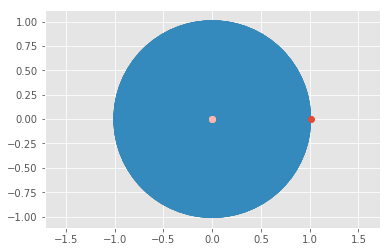

[ 1.25836620e+00+0.00000000e+00j  3.84017875e-03+0.00000000e+00j
  2.52156848e-05+0.00000000e+00j  3.00736664e-07+0.00000000e+00j
  5.06364866e-09+0.00000000e+00j  1.00516376e-10+0.00000000e+00j
  2.57911075e-12+0.00000000e+00j  8.41500194e-14+0.00000000e+00j
  2.74688967e-15+0.00000000e+00j  8.70801048e-17+0.00000000e+00j
  3.04514407e-18+0.00000000e+00j  6.80173630e-19+0.00000000e+00j
  7.19510913e-20+0.00000000e+00j -7.58692188e-21+3.58131422e-20j
 -7.58692188e-21-3.58131422e-20j  7.63127959e-21+1.57069121e-20j
  7.63127959e-21-1.57069121e-20j  1.21497900e-20+0.00000000e+00j
 -5.09065883e-21+1.09588603e-21j -5.09065883e-21-1.09588603e-21j
  1.05716933e-21+0.00000000e+00j -2.23862881e-22+0.00000000e+00j
  1.11834560e-22+0.00000000e+00j -1.05614800e-23+0.00000000e+00j
  4.76315585e-24+0.00000000e+00j -2.53498228e-24+0.00000000e+00j
  2.57833946e-25+0.00000000e+00j  1.40074077e-25+0.00000000e+00j
  3.19310762e-26+0.00000000e+00j -4.91538801e-27+0.00000000e+00j
 -1.18607118e-27+0.000000

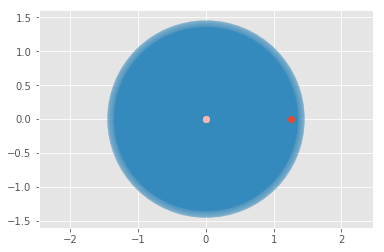

[ 1.05301995e+00+0.00000000e+00j  2.82658199e-04+0.00000000e+00j
  1.92745409e-07+0.00000000e+00j  2.56648821e-10+0.00000000e+00j
  6.14833357e-13+0.00000000e+00j  1.68120901e-15+0.00000000e+00j
  4.94092176e-18+0.00000000e+00j  1.67659020e-20+0.00000000e+00j
 -5.73253652e-22+0.00000000e+00j  9.38652778e-24+5.79567328e-24j
  9.38652778e-24-5.79567328e-24j -9.01825119e-25+0.00000000e+00j
  6.91878890e-26+0.00000000e+00j -3.02143630e-28+0.00000000e+00j
  5.22572496e-29+0.00000000e+00j  5.09192605e-30+0.00000000e+00j
  4.35466999e-31+0.00000000e+00j  6.64314239e-33+0.00000000e+00j
 -1.51156099e-33+0.00000000e+00j -2.94389095e-34+0.00000000e+00j
  2.79937532e-37+0.00000000e+00j -1.54260533e-36+0.00000000e+00j
  1.04622823e-38+0.00000000e+00j  2.85490436e-40+0.00000000e+00j
  5.10286241e-41+0.00000000e+00j  6.40975979e-42+0.00000000e+00j
 -3.34986824e-44+2.34281933e-43j -3.34986824e-44-2.34281933e-43j
  2.52018966e-45+0.00000000e+00j -1.70460359e-45+0.00000000e+00j
 -1.14532349e-45+0.000000

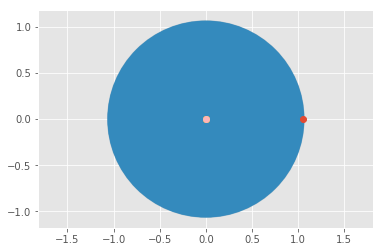

[ 1.03719265e+00+0.00000000e+00j  8.17407626e-04+0.00000000e+00j
  1.78666797e-06+0.00000000e+00j  4.05781364e-09+0.00000000e+00j
  7.91827163e-12+0.00000000e+00j  1.43314865e-14+0.00000000e+00j
  3.52820186e-17+0.00000000e+00j  9.65170448e-20+0.00000000e+00j
  2.50029472e-22+0.00000000e+00j -2.67284841e-24+0.00000000e+00j
  2.17639775e-25+0.00000000e+00j  4.67529341e-27+0.00000000e+00j
  3.55549210e-28+0.00000000e+00j -5.53804288e-29+0.00000000e+00j
  1.76868512e-29+0.00000000e+00j  2.67432229e-32+0.00000000e+00j
 -7.10374911e-34+0.00000000e+00j  5.39737799e-35+0.00000000e+00j
  2.08083443e-37+0.00000000e+00j  9.37463224e-39+0.00000000e+00j
 -1.71356764e-39+0.00000000e+00j -2.54133366e-40+1.46767612e-40j
 -2.54133366e-40-1.46767612e-40j  6.91196351e-43+1.29317005e-42j
  6.91196351e-43-1.29317005e-42j -8.52485116e-45+0.00000000e+00j
  9.09214920e-46+0.00000000e+00j -2.68542738e-46+0.00000000e+00j
  1.03942114e-47+0.00000000e+00j -1.21214812e-48+0.00000000e+00j
 -1.69165964e-49+0.000000

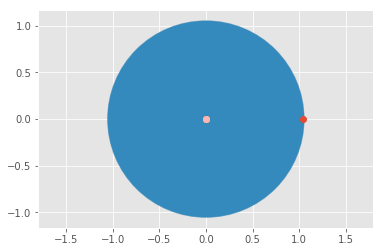

[ 1.40529772e+00+0.00000000e+00j  1.02236475e-02+0.00000000e+00j
  1.37064508e-04+0.00000000e+00j  2.30856464e-06+0.00000000e+00j
  4.73800856e-08+0.00000000e+00j  1.16147571e-09+0.00000000e+00j
  3.00871082e-11+0.00000000e+00j  8.04065597e-13+0.00000000e+00j
  2.23515291e-14+0.00000000e+00j  6.39621028e-16+0.00000000e+00j
  1.94299624e-17+0.00000000e+00j  3.98346942e-18+0.00000000e+00j
  3.07080078e-19+0.00000000e+00j  1.63074552e-19+1.30528181e-19j
  1.63074552e-19-1.30528181e-19j  1.82942338e-20+3.34638721e-20j
  1.82942338e-20-3.34638721e-20j -9.54681291e-21+1.28977950e-20j
 -9.54681291e-21-1.28977950e-20j  3.44647443e-21+0.00000000e+00j
  1.72705244e-21+0.00000000e+00j  4.11958253e-24+2.22410426e-22j
  4.11958253e-24-2.22410426e-22j  2.03049483e-22+0.00000000e+00j
 -2.06264824e-23+8.57356453e-23j -2.06264824e-23-8.57356453e-23j
  7.64113888e-24+0.00000000e+00j -2.54914610e-24+0.00000000e+00j
 -7.28278738e-25+5.18739459e-25j -7.28278738e-25-5.18739459e-25j
  3.60496701e-26+0.000000

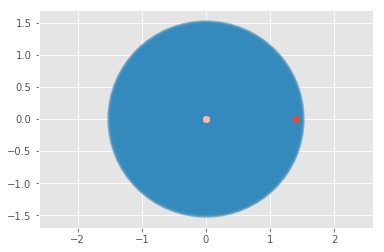

[ 1.54781960e+00+0.00000000e+00j  1.03157074e-02+0.00000000e+00j
  1.15136350e-04+0.00000000e+00j  1.59549801e-06+0.00000000e+00j
  2.24876322e-08+0.00000000e+00j  2.69251726e-10+0.00000000e+00j
  2.44783588e-12+0.00000000e+00j  1.82695440e-14+0.00000000e+00j
  1.80733075e-16+0.00000000e+00j  5.86882085e-18+3.15175618e-18j
  5.86882085e-18-3.15175618e-18j -1.84200180e-19+2.19826966e-18j
 -1.84200180e-19-2.19826966e-18j -4.59715652e-19+0.00000000e+00j
 -3.76246649e-19+0.00000000e+00j  5.55367301e-20+4.23857425e-20j
  5.55367301e-20-4.23857425e-20j  3.42479275e-20+7.63166799e-21j
  3.42479275e-20-7.63166799e-21j  7.35535328e-21+0.00000000e+00j
 -3.62536612e-21+1.50487269e-21j -3.62536612e-21-1.50487269e-21j
 -7.74371270e-22+0.00000000e+00j -1.63994008e-22+2.23807083e-22j
 -1.63994008e-22-2.23807083e-22j  2.58540946e-22+0.00000000e+00j
 -6.20227970e-23+0.00000000e+00j  6.20840238e-23+0.00000000e+00j
  8.08766544e-24+4.13862145e-23j  8.08766544e-24-4.13862145e-23j
  3.50913933e-23+0.000000

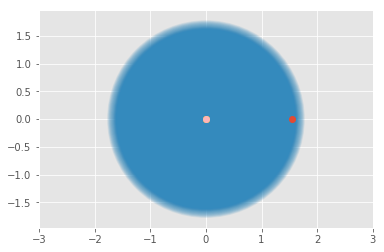

In [11]:
for i in list(range(data.shape[0])):
    vector=data.iloc[i].values/M
    V=np.vander(vector,len(vector),increasing=True)
    myGerschgorin(V)